# Определение возраста покупателей

## **Описание проекта**

**Сетевой супермаркет «Хлеб-Соль»** внедряет систему компьютерного зрения для обработки фотографий покупателей. 


**Фотофиксация в прикассовой зоне поможет определять возраст клиентов**, чтобы:
> • **анализировать покупки и предлагать товары**, которые могут заинтересовать покупателей этой возрастной группы;

> • **контролировать добросовестность кассиров при продаже алкоголя**.


Постройте модель, которая по фотографии определит приблизительный возраст человека. В вашем распоряжении набор фотографий людей с указанием возраста.

### План работы

1. Проведите исследовательский анализ набора фотографий.

2. Подготовьте данные к обучению.

3. Обучите нейронную сеть и рассчитайте её качество.

### Описание данных

Данные взяты с сайта [ChaLearn Looking at People](https://chalearnlap.cvc.uab.cat/dataset/26/description/). 

Они находятся в папке `/datasets/faces/`.


В вашем распоряжении одна папка со всеми изображениями `(/final_files)` и CSV-файл `labels.csv` с двумя колонками: `file_name` и `real_age`.


Извлечь данные из папки вам поможет новый метод [ImageDataGenerator](https://keras.io/api/preprocessing/image/) — `flow_from_dataframe(dataframe, directory, ...)`.

## Исследовательский анализ данных

In [1]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
import plotly.io as pio
pio.renderers.default = "iframe"

In [3]:
labels = pd.read_csv('/datasets/faces/labels.csv')

labels.head(10)

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17
5,000005.jpg,27
6,000006.jpg,24
7,000007.jpg,43
8,000008.jpg,26
9,000009.jpg,39


In [4]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [5]:
labels['real_age'].describe()

count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64

In [6]:
print('Количество уникальных значений возраста людей :', labels['real_age'].nunique())

Количество уникальных значений возраста людей : 97


Файл содержит 7591 строк, две колонки: `file_name` название изображения, `real_age` возраст человека на фото.

In [7]:
# строим график распределения возраста людей

fig = px.histogram(labels, x='real_age', 
                   nbins=100, 
                   marginal='box'
                  )
    
fig.update_layout(title='График распределения возраста', 
                  title_x=0.5, 
                  margin=dict(t=50, l=0, r=0, b=0),  
                  bargap=0.1
                 )
fig.show()

Датасет охватывает все возрастные группы, большее количество соответствует возрасту примерно 20 - 30 лет.

In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345) 

features, target = next(train_gen_flow)

Found 7591 validated image filenames.


In [9]:
features.shape, target.shape

((32, 224, 224, 3), (32,))

In [10]:
fig = px.imshow(features[0:16], 
                binary_string=True, 
                facet_col=0, 
                facet_col_wrap=4)
     
annotations = fig.layout.annotations                    
annotation_order = []

for annotation in annotations:
    text = annotation['text']
    number = re.findall(r'\d+', text)
    if number:
        annotation_order.append(int(number[0]))

for i, age in enumerate(target[:16]):
    annotation_index = annotation_order[i]
    fig.layout.annotations[annotation_index]['text'] = f'Возраст <b>{age} лет'
        
fig.update_layout(margin=dict(t=80, l=0, r=0, b=0),
                  title="Изображения обучающей выборки", 
                  title_x=0.5,
                  width=900,
                  height=900 
                  )

fig.show()

- Разметка, насколько можно судить, выполнена корректно.

- В датасете представлены фото людей разного возраста, пола и расы, в разных ракурсах и разными выражениями лица, что должно не допустить переобучения модели.

**Вывод по разделу #2:**

- Датасет охватывает все возрастные группы, распределение по возрасту *не равномерное*.
- Минимальный возраст на фото - 1 год, максимальный - 100 лет. Cредний возраст составляет 31 год, медианное значение возраста -29 лет. IQR составляет 21 год от 20 до 41 года. Верхняя граница выбросов, рассчитанная по IQR составляет 72 года.
- На графике наблюдаются пики на возрасте: 1 год, 25 лет, 30 лет, 40 лет, 50 лет, 60 лет, 70 лет, 80 лет, 90 лет. 

Для стабильности обучения модели:
- значения пикселей изображений приведены к диапазону от 0 до 1, так как значения пикселей изображения обычно представляются целыми числами от 0 до 255 для каждого цветового канала (красного, зеленого и синего). Таким образом, изменение масштаба значений пикселей путем деления их на 255 гарантирует, что значения пикселей будут нормализованы в диапазоне от 0 до 1.
- размеры изображений преобразованы к единому размеру квадратной формы с шириной и высотой 224 пикселя. 
- для улучшения качества модели и предотвращения переобучения следует применить аугментацию данных.

## Обучение модели

Код обучения модели и её результат вывода на экран.


**Код из этого раздела запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке.**

```
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.optimizers import Adam

def load_train(path):
    labels = pd.read_csv(path+'labels.csv')
    train_datagen = ImageDataGenerator(
                    horizontal_flip=True,
                    rescale=1/255,
                    validation_split=0.25)
    train_data = train_datagen.flow_from_dataframe(
    dataframe=labels,
    x_col='file_name',
    y_col='real_age',
    directory=path+'final_files/',
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    subset='training',
    seed=12345) 

    return train_data 

def load_test(path):
    labels = pd.read_csv(path+'labels.csv')
    test_datagen = ImageDataGenerator(
                    rescale=1/255,
                    validation_split=0.25)
    test_data = test_datagen.flow_from_dataframe(
    dataframe=labels,
    x_col='file_name',
    y_col='real_age',
    directory=path+'final_files/',
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    subset='validation',
    seed=12345) 

    return test_data
    

def create_model(input_shape):
    backbone = ResNet50(input_shape=input_shape,
                    weights='imagenet', 
                    include_top=False)
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(units=1, activation='relu'))
 
    model.compile(optimizer=Adam(lr=0.0005), loss='mean_squared_error', 
              metrics=['mean_absolute_error']) 
    return model

 
def train_model(model, train_data, test_data, epochs=10, batch_size=None,
               steps_per_epoch=None, validation_steps=None):
    
    
    model.fit(train_data,
            validation_data=test_data, 
            batch_size=batch_size,
            epochs=epochs,
            steps_per_epoch=steps_per_epoch,
            validation_steps=validation_steps,
            verbose=2)
 
    return model
```

```
Found 5694 validated image filenames.
Found 1897 validated image filenames.
Train for 178 steps, validate for 60 steps
Epoch 1/10
2023-05-12 03:59:08.698122: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2023-05-12 03:59:09.242838: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
178/178 - 66s - loss: 240.9812 - mean_absolute_error: 11.2407 - val_loss: 418.3780 - val_mean_absolute_error: 15.4185
Epoch 2/10
178/178 - 49s - loss: 110.5081 - mean_absolute_error: 7.9883 - val_loss: 288.0288 - val_mean_absolute_error: 12.8268
Epoch 3/10
178/178 - 50s - loss: 88.3994 - mean_absolute_error: 7.1044 - val_loss: 318.0444 - val_mean_absolute_error: 13.1886
Epoch 4/10
178/178 - 50s - loss: 67.6569 - mean_absolute_error: 6.2665 - val_loss: 183.5774 - val_mean_absolute_error: 10.0877
Epoch 5/10
178/178 - 49s - loss: 53.8010 - mean_absolute_error: 5.6393 - val_loss: 113.6962 - val_mean_absolute_error: 8.1239
Epoch 6/10
178/178 - 45s - loss: 44.9411 - mean_absolute_error: 5.1463 - val_loss: 88.5436 - val_mean_absolute_error: 7.0721
Epoch 7/10
178/178 - 37s - loss: 39.5807 - mean_absolute_error: 4.8581 - val_loss: 108.8129 - val_mean_absolute_error: 7.7560
Epoch 8/10
178/178 - 39s - loss: 34.0343 - mean_absolute_error: 4.4687 - val_loss: 90.4466 - val_mean_absolute_error: 7.3509
Epoch 9/10
178/178 - 38s - loss: 28.3904 - mean_absolute_error: 4.1105 - val_loss: 164.2811 - val_mean_absolute_error: 10.1312
Epoch 10/10
178/178 - 47s - loss: 24.5519 - mean_absolute_error: 3.7431 - val_loss: 79.3120 - val_mean_absolute_error: 6.7280
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
60/60 - 10s - loss: 79.3120 - mean_absolute_error: 6.7280
Test MAE: 6.7280
```

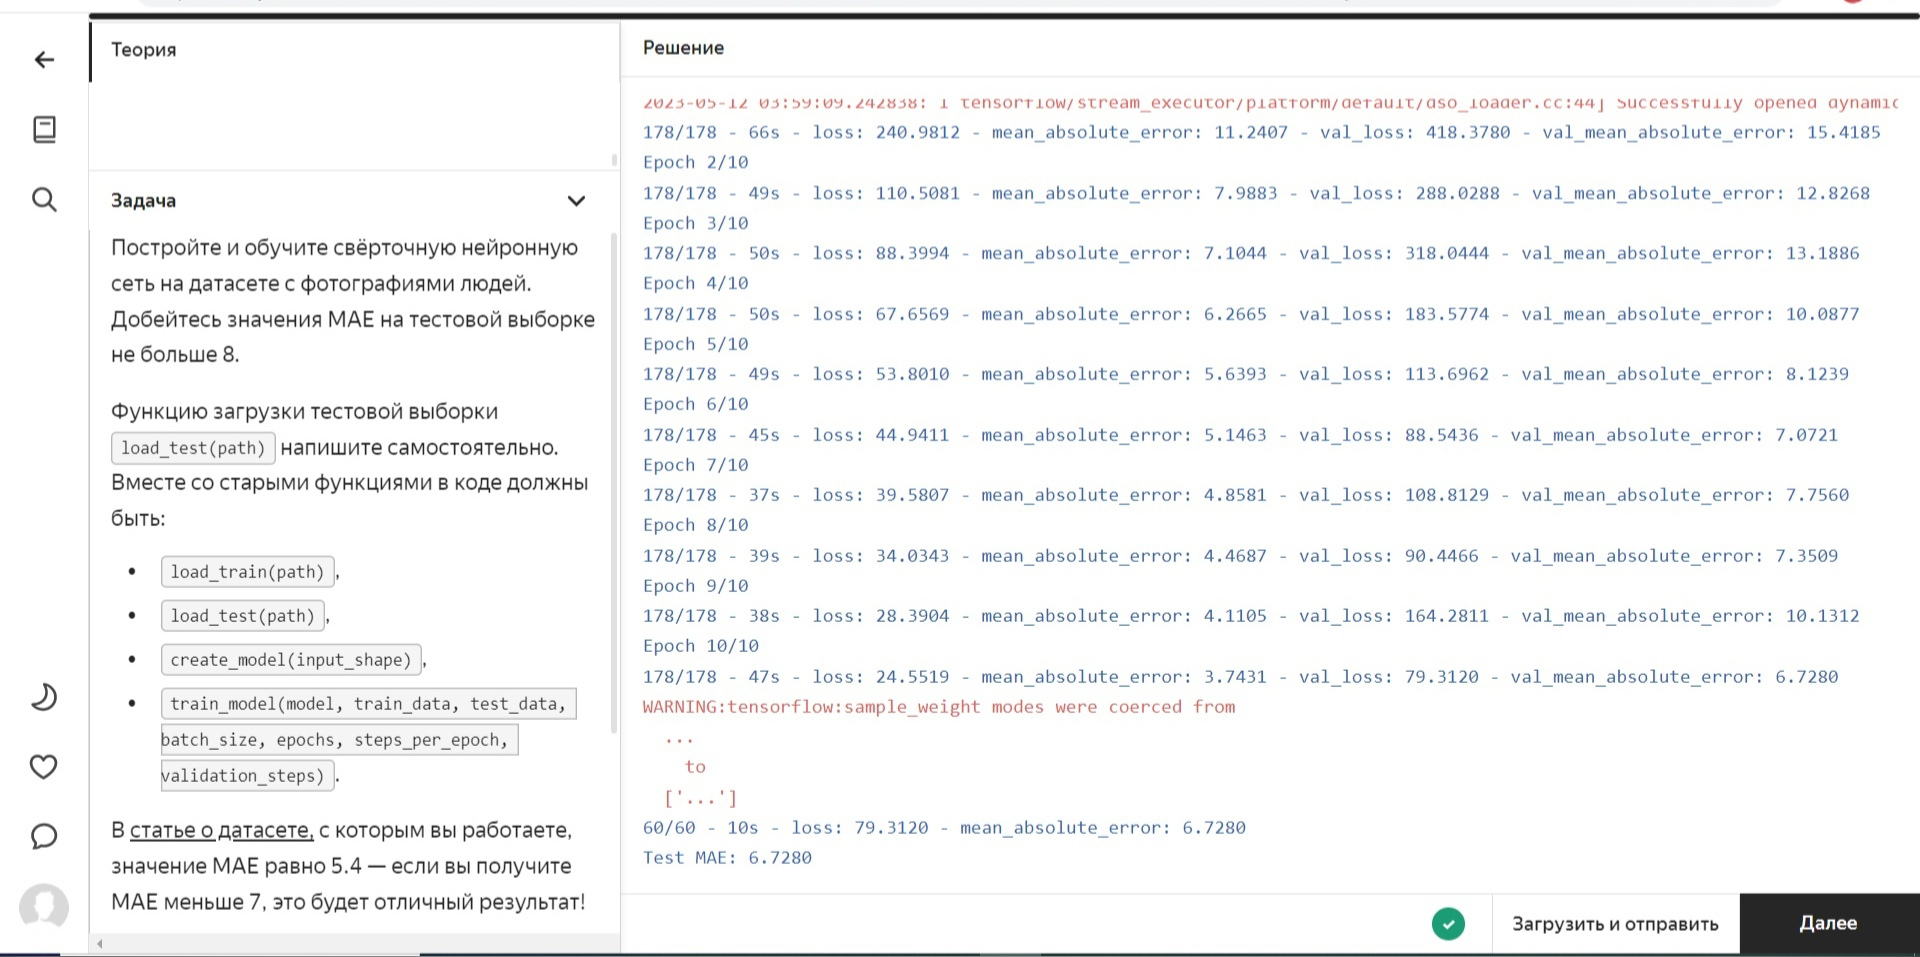

## Анализ обученной модели

- Обучена CNN на базе архитектуры ResNet50, решена задача регрессии по определению возраста людей по фото.
- Значение метрики MAE на тестовой выборке составило не более 8 (лет) согласно поставленной задаче.
- Для решения задачи по анализу покупок и рекомендациям покупателям точность модели представляется вполне приемлимой, однако не достаточна для задачи по контролю добросовестности кассиров.